
# PCA from Scratch (Linear Algebra + Full Math + Worked Examples + Bird Dataset)

This notebook is a **from-first-principles** walkthrough of Principal Component Analysis (PCA):

- Basic concepts: mean, centering, covariance, eigen-decomposition
- Why eigenvectors of the covariance matrix are principal directions (**Rayleigh quotient** proof)
- Worked 2D examples
- **Exercise 2**: full *by-hand* eigenvalue/eigenvector derivation + computational verification
- Bird dataset example (3 variables): covariance, eigenvalues, explained variance, loadings, projection, reconstruction

We implement **covariance PCA** (not SVD-first), matching the linear-algebra approach in the notes.


In [4]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)



## 1. Notation and the PCA pipeline

We have data vectors (samples) in $\mathbb{R}^m$:
$$
\mathbf{x}_1, \ldots, \mathbf{x}_n \in \mathbb{R}^m.
$$

Define the **mean vector**
$$
\boldsymbol{\mu} = \frac{1}{n}\sum_{i=1}^n \mathbf{x}_i.
$$

Define **centered vectors**
$$
\mathbf{y}_i = \mathbf{x}_i - \boldsymbol{\mu}.
$$

Stack centered samples into a matrix $Y \in \mathbb{R}^{n\times m}$ with rows $\mathbf{y}_i^\top$.
Then the **sample covariance matrix** is
$$
S = \frac{1}{n-1} Y^\top Y \in \mathbb{R}^{m\times m}.
$$

PCA uses eigenpairs $S \mathbf{u}_k = \lambda_k \mathbf{u}_k$ with $\lambda_1 \ge \cdots \ge \lambda_m \ge 0$.

- The **principal directions** are $\mathbf{u}_k$.
- The **variance explained** by direction $\mathbf{u}_k$ is $\lambda_k$.
- The **explained variance ratio** is $\lambda_k / \sum_j \lambda_j$.

Projection onto first $k$ PCs:
$$
Z = Y U_k,\quad U_k=[\mathbf{u}_1~\cdots~\mathbf{u}_k]\in\mathbb{R}^{m\times k}.
$$

Reconstruction in the original space:
$$
\hat{X} = \mathbf{1}\boldsymbol{\mu}^\top + Z U_k^\top.
$$


In [5]:

def center(X):
    """Center rows of X (shape n x m). Returns centered matrix Y and mean mu (shape m,)."""
    mu = X.mean(axis=0)
    Y = X - mu
    return Y, mu

def covariance_matrix(Y, ddof=1):
    """Sample covariance of centered data Y (n x m): S = 1/(n-ddof) Y^T Y."""
    n = Y.shape[0]
    return (Y.T @ Y) / (n - ddof)

def pca_from_cov(S):
    """Eigen-decomposition of symmetric covariance matrix S. Returns eigenvalues (desc) and eigenvectors (columns)."""
    evals, evecs = np.linalg.eigh(S)  # ascending
    idx = np.argsort(evals)[::-1]
    return evals[idx], evecs[:, idx]

def explained_variance_ratio(evals):
    total = float(np.sum(evals))
    return evals / total if total > 0 else np.zeros_like(evals)

def project(Y, U, k):
    """Project centered data Y (n x m) onto first k PCs (columns of U)."""
    return Y @ U[:, :k]

def reconstruct(Z, mu, U, k):
    """Reconstruct from PCA coordinates Z using first k PCs."""
    return mu + Z @ U[:, :k].T



## 2. Why PCA directions maximize variance (full math)

Let $S$ be the covariance matrix of centered data in $\mathbb{R}^m$.

For any unit vector $\mathbf{v}$ with $\|\mathbf{v}\|=1$, the variance of the data when projected onto $\mathbf{v}$ is
$$
\mathrm{Var}(\mathbf{v}^\top \mathbf{y}) = \mathbf{v}^\top S \mathbf{v}.
$$

**Derivation** (with centered samples $\mathbf{y}_i$):
Let $t_i = \mathbf{v}^\top \mathbf{y}_i$. Then
$$
\frac{1}{n-1}\sum_{i=1}^n t_i^2
= \frac{1}{n-1}\sum_{i=1}^n (\mathbf{v}^\top \mathbf{y}_i)^2
= \frac{1}{n-1}\sum_{i=1}^n \mathbf{v}^\top \mathbf{y}_i\mathbf{y}_i^\top \mathbf{v}
= \mathbf{v}^\top \left(\frac{1}{n-1}\sum_{i=1}^n \mathbf{y}_i\mathbf{y}_i^\top\right)\mathbf{v}
= \mathbf{v}^\top S \mathbf{v}.
$$

So PC1 solves the constrained optimization:
$$
\max_{\|\mathbf{v}\|=1}\; \mathbf{v}^\top S \mathbf{v}.
$$

### Lagrange multiplier proof
Define the Lagrangian
$$
\mathcal{L}(\mathbf{v},\alpha)=\mathbf{v}^\top S \mathbf{v}-\alpha(\mathbf{v}^\top\mathbf{v}-1).
$$
Taking derivative w.r.t. $\mathbf{v}$ and setting to zero gives
$$
\nabla_{\mathbf{v}}\mathcal{L}=2S\mathbf{v}-2\alpha\mathbf{v}=0 \quad\Rightarrow\quad S\mathbf{v}=\alpha\mathbf{v}.
$$
Hence stationary points are eigenvectors, and the objective at an eigenvector $\mathbf{u}_k$ is $\lambda_k$:
$$
\mathbf{u}_k^\top S \mathbf{u}_k = \lambda_k.
$$
Therefore the maximum is $\lambda_1$, achieved at the top eigenvector $\mathbf{u}_1$.



## 3. Warm-up: PCA pipeline on a synthetic 2D dataset
We create a cloud elongated along a diagonal direction, then:
- center it
- compute covariance
- eigen-decompose
- project onto PC1
- reconstruct and visualize


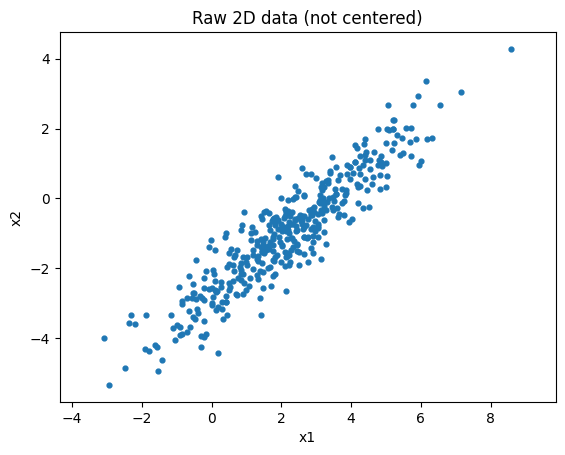

In [6]:

# Generate correlated 2D Gaussian data
rng = np.random.default_rng(7)
n = 400
Sigma = np.array([[4.0, 3.2],
                  [3.2, 3.0]])
X = rng.multivariate_normal(mean=[2.0, -1.0], cov=Sigma, size=n)  # (n,2)

plt.figure()
plt.scatter(X[:,0], X[:,1], s=12)
plt.title("Raw 2D data (not centered)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()


In [8]:

Y, mu = center(X)
S = covariance_matrix(Y, ddof=1)
evals, U = pca_from_cov(S)

print("Mean mu =", mu)
print("\nCovariance S =\n", S)
print("\nEigenvalues (desc) =", evals)
print("Explained variance ratio =", explained_variance_ratio(evals))
print("First eigenvector u1 =", U[:,0])


Mean mu = [ 2.154555 -0.975884]

Covariance S =
 [[3.575218 2.803966]
 [2.803966 2.589071]]

Eigenvalues (desc) = [5.929133 0.235155]
Explained variance ratio = [0.961852 0.038148]
First eigenvector u1 = [-0.765895 -0.642965]


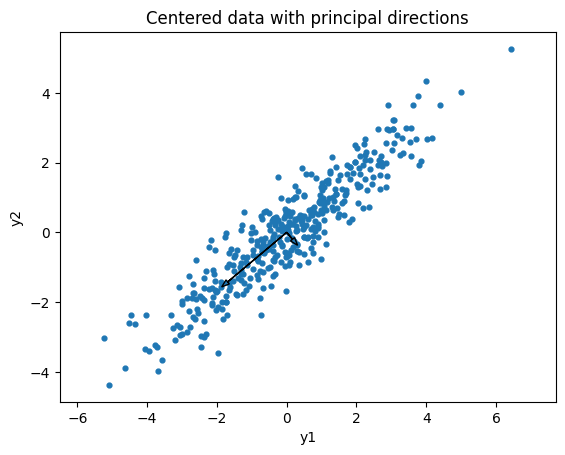

In [9]:

plt.figure()
plt.scatter(Y[:,0], Y[:,1], s=12)
plt.title("Centered data with principal directions")
plt.xlabel("y1")
plt.ylabel("y2")
plt.axis("equal")

origin = np.zeros(2)
for k in range(2):
    vec = U[:,k] * np.sqrt(evals[k])
    plt.arrow(origin[0], origin[1], vec[0], vec[1],
              length_includes_head=True, head_width=0.15)
plt.show()


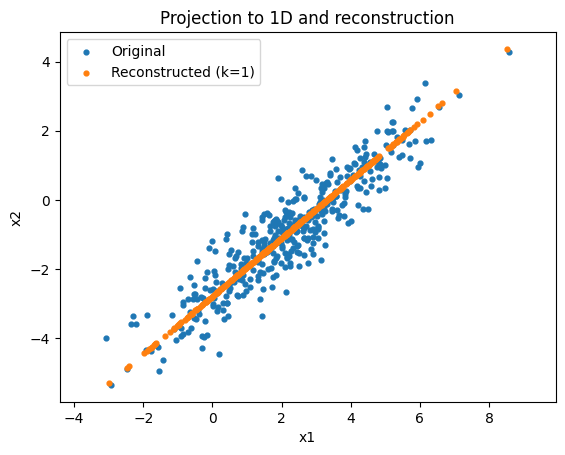

Reconstruction MSE (k=1): 0.11728363393339965


In [12]:

Z1 = project(Y, U, k=1)      # (n,1)
Xhat1 = reconstruct(Z1, mu, U, k=1)

plt.figure()
plt.scatter(X[:,0], X[:,1], s=12, label="Original")
plt.scatter(Xhat1[:,0], Xhat1[:,1], s=12, label="Reconstructed (k=1)")
plt.title("Projection to 1D and reconstruction")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend()
plt.show()

mse1 = float(np.mean((X - Xhat1)**2))
print("Reconstruction MSE (k=1):", mse1)



## 4. Worked 2D matrix example: $S=\begin{bmatrix}95&1\\1&5\end{bmatrix}$
Compute eigenvalues/eigenvectors and interpret $\lambda_1\gg\lambda_2$ as “nearly 1D” variation.


In [7]:

S1 = np.array([[95.0, 1.0],
               [1.0,  5.0]])
evals1, U1 = pca_from_cov(S1)

print("S =\n", S1)
print("Eigenvalues:", evals1)
print("Eigenvectors (columns):\n", U1)
print("Explained variance ratio:", explained_variance_ratio(evals1))


S =
 [[95.  1.]
 [ 1.  5.]]
Eigenvalues: [95.01111  4.98889]
Eigenvectors (columns):
 [[-0.999938  0.011109]
 [-0.011109 -0.999938]]
Explained variance ratio: [0.950111 0.049889]



## 5. Exercise 2 (FULL BY-HAND MATH) + Verification

Given
$$
S=\begin{bmatrix}50&40\\40&50\end{bmatrix}.
$$

### 5.1 Characteristic polynomial
$$
\det(S-\lambda I)
= \det\begin{bmatrix}50-\lambda & 40\\ 40 & 50-\lambda\end{bmatrix}
= (50-\lambda)^2 - 40^2.
$$
Set determinant to 0:
$$
(50-\lambda)^2 - 1600 = 0
\Rightarrow (50-\lambda)^2 = 1600
\Rightarrow 50-\lambda = \pm 40.
$$
So
$$
\lambda_1=90,\quad \lambda_2=10.
$$

### 5.2 Eigenvectors
For $\lambda_1=90$:
$$
(S-90I)\mathbf{u}=0,\quad
S-90I=\begin{bmatrix}-40&40\\40&-40\end{bmatrix}
\Rightarrow u_1=u_2.
$$
Normalized eigenvector:
$$
\mathbf{u}_1=\frac{1}{\sqrt{2}}\begin{bmatrix}1\\1\end{bmatrix}.
$$

For $\lambda_2=10$:
$$
(S-10I)\mathbf{u}=0,\quad
S-10I=\begin{bmatrix}40&40\\40&40\end{bmatrix}
\Rightarrow u_1=-u_2.
$$
Normalized eigenvector:
$$
\mathbf{u}_2=\frac{1}{\sqrt{2}}\begin{bmatrix}-1\\1\end{bmatrix}.
$$

(**Sign is arbitrary:** $\mathbf{u}$ and $-\mathbf{u}$ represent the same axis.)


In [8]:

S2 = np.array([[50.0, 40.0],
               [40.0, 50.0]])

lam_hand = np.array([90.0, 10.0])
u1_hand = (1/np.sqrt(2))*np.array([1.0, 1.0])
u2_hand = (1/np.sqrt(2))*np.array([-1.0, 1.0])

evals2, U2 = pca_from_cov(S2)

print("S =\n", S2)
print("\nNumerical eigenvalues:", evals2)
print("Numerical eigenvectors (columns):\n", U2)

res1 = np.linalg.norm(S2 @ u1_hand - lam_hand[0]*u1_hand)
res2 = np.linalg.norm(S2 @ u2_hand - lam_hand[1]*u2_hand)
print("\nResiduals (by-hand):")
print("||S u1 - 90 u1|| =", res1)
print("||S u2 - 10 u2|| =", res2)

dot1 = float(np.dot(U2[:,0], u1_hand))
dot2 = float(np.dot(U2[:,1], u2_hand))
print("\nDot products with by-hand eigenvectors (±1 means same direction):")
print("dot(U_num[:,0], u1_hand) =", dot1)
print("dot(U_num[:,1], u2_hand) =", dot2)


S =
 [[50. 40.]
 [40. 50.]]

Numerical eigenvalues: [90. 10.]
Numerical eigenvectors (columns):
 [[ 0.707107 -0.707107]
 [ 0.707107  0.707107]]

Residuals (by-hand):
||S u1 - 90 u1|| = 7.105427357601002e-15
||S u2 - 10 u2|| = 2.6645352591003757e-15

Dot products with by-hand eigenvectors (±1 means same direction):
dot(U_num[:,0], u1_hand) = 0.9999999999999998
dot(U_num[:,1], u2_hand) = 0.9999999999999998


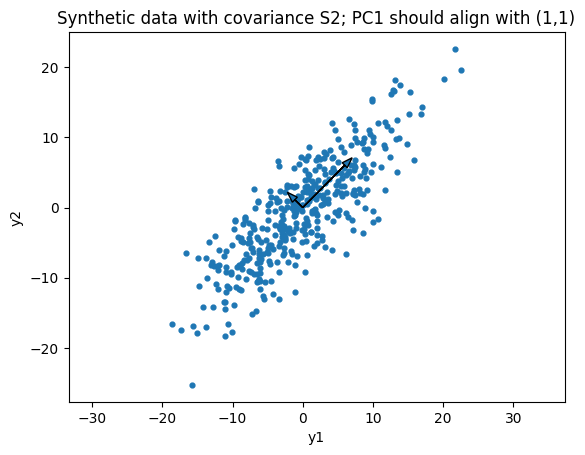

Estimated PC1 direction: [0.704988 0.709219]
Explained variance ratio: [0.913601 0.086399]


In [9]:

# Geometry: synthetic data with covariance S2
rng = np.random.default_rng(123)
n2 = 400
Y2 = rng.multivariate_normal(mean=[0.0, 0.0], cov=S2, size=n2)  # already centered

S2_emp = covariance_matrix(Y2, ddof=1)
evals2_emp, U2_emp = pca_from_cov(S2_emp)

plt.figure()
plt.scatter(Y2[:,0], Y2[:,1], s=12)
plt.title("Synthetic data with covariance S2; PC1 should align with (1,1)")
plt.xlabel("y1")
plt.ylabel("y2")
plt.axis("equal")

origin = np.zeros(2)
for k in range(2):
    vec = U2_emp[:,k] * np.sqrt(evals2_emp[k])
    plt.arrow(origin[0], origin[1], vec[0], vec[1],
              length_includes_head=True, head_width=1.0)
plt.show()

print("Estimated PC1 direction:", U2_emp[:,0])
print("Explained variance ratio:", explained_variance_ratio(evals2_emp))



## 6. Total variance and trace identity (full math)

Total variance across all coordinates:
$$
T = \sum_{j=1}^m S_{jj} = \mathrm{tr}(S).
$$

Since the trace equals the sum of eigenvalues,
$$
\mathrm{tr}(S) = \sum_{k=1}^m \lambda_k,
$$
the explained variance ratio is
$$
\mathrm{EVR}_k = \frac{\lambda_k}{\sum_j \lambda_j}.
$$


In [10]:

rng = np.random.default_rng(99)
Xr = rng.normal(size=(200, 5))
Yr, _ = center(Xr)
Sr = covariance_matrix(Yr, ddof=1)
evalsr, _ = pca_from_cov(Sr)

print("trace(S) =", np.trace(Sr))
print("sum eigenvalues =", np.sum(evalsr))
print("difference =", np.trace(Sr) - np.sum(evalsr))


trace(S) = 5.009292103801572
sum eigenvalues = 5.009292103801571
difference = 8.881784197001252e-16



## 7. Bird dataset example (3 variables)

We create synthetic "bird" measurements:
- length
- wingspan
- weight

Construction uses two latent factors:
- **size** increases all measurements (PC1 should have all-positive loadings)
- **shape** trades wingspan vs weight (PC2 should show opposite signs)


In [11]:

rng = np.random.default_rng(2025)
n_birds = 250

size = rng.normal(0.0, 1.0, size=n_birds)
shape = rng.normal(0.0, 1.0, size=n_birds)

length = 30 + 4.0*size + 0.6*rng.normal(size=n_birds)
wingspan = 70 + 7.0*size + 3.0*shape + 0.8*rng.normal(size=n_birds)
weight = 2.0 + 0.9*size - 0.7*shape + 0.25*rng.normal(size=n_birds)

Xb = np.column_stack([length, wingspan, weight])  # (n,3)

print("First 5 rows [length, wingspan, weight]:\n", Xb[:5])
print("\nMeans:", Xb.mean(axis=0))
print("Std devs:", Xb.std(axis=0, ddof=1))


First 5 rows [length, wingspan, weight]:
 [[20.944283 48.421946  1.26324 ]
 [30.453273 71.672827  2.009649]
 [28.041057 69.895776  0.806667]
 [25.62269  54.957225  2.518457]
 [20.325065 55.75912  -0.786893]]

Means: [29.92923  69.686977  1.93868 ]
Std devs: [4.541883 8.429944 1.210433]


In [12]:

Yb, mub = center(Xb)
Sb = covariance_matrix(Yb, ddof=1)
evalsb, Ub = pca_from_cov(Sb)
evr_b = explained_variance_ratio(evalsb)

print("Covariance matrix S (birds)=\n", Sb)
print("\nEigenvalues:", evalsb)
print("Explained variance ratio:", evr_b)
print("\nEigenvectors (columns = PCs)=\n", Ub)
print("\ntrace(S) =", np.trace(Sb), " sum eigenvalues =", np.sum(evalsb))


Covariance matrix S (birds)=
 [[20.628699 35.607262  4.398977]
 [35.607262 71.063952  5.827977]
 [ 4.398977  5.827977  1.465149]]

Eigenvalues: [90.063757  2.942607  0.151436]
Explained variance ratio: [0.966787 0.031587 0.001626]

Eigenvectors (columns = PCs)=
 [[-0.458871 -0.744023 -0.485661]
 [-0.884805  0.432476  0.173451]
 [-0.080985 -0.509307  0.856766]]

trace(S) = 93.15780004135861  sum eigenvalues = 93.15780004135857



### 7.1 Interpreting eigenvectors ("loadings")

For PC $k$, the eigenvector
$\mathbf{u}_k=(u_{1k},u_{2k},u_{3k})^\top$ gives loadings on:
- length
- wingspan
- weight

Large $|u_{jk}|$ means feature $j$ contributes strongly to PC $k$.

Opposite signs indicate a trade-off between features along that component.


In [13]:

feature_names = ["length", "wingspan", "weight"]

print("Loadings (feature contributions)")
for k in range(3):
    print(f"\nPC{k+1}: eigenvalue={evalsb[k]:.6f}, EVR={evr_b[k]:.4f}")
    for j, name in enumerate(feature_names):
        print(f"  {name:8s}: {Ub[j,k]: .6f}")


Loadings (feature contributions)

PC1: eigenvalue=90.063757, EVR=0.9668
  length  : -0.458871
  wingspan: -0.884805
  weight  : -0.080985

PC2: eigenvalue=2.942607, EVR=0.0316
  length  : -0.744023
  wingspan:  0.432476
  weight  : -0.509307

PC3: eigenvalue=0.151436, EVR=0.0016
  length  : -0.485661
  wingspan:  0.173451
  weight  :  0.856766


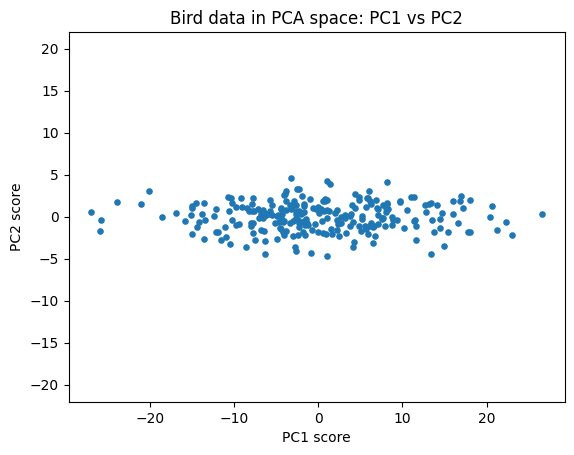

In [14]:

Zb = project(Yb, Ub, k=3)  # (n,3)

plt.figure()
plt.scatter(Zb[:,0], Zb[:,1], s=14)
plt.title("Bird data in PCA space: PC1 vs PC2")
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.axis("equal")
plt.show()


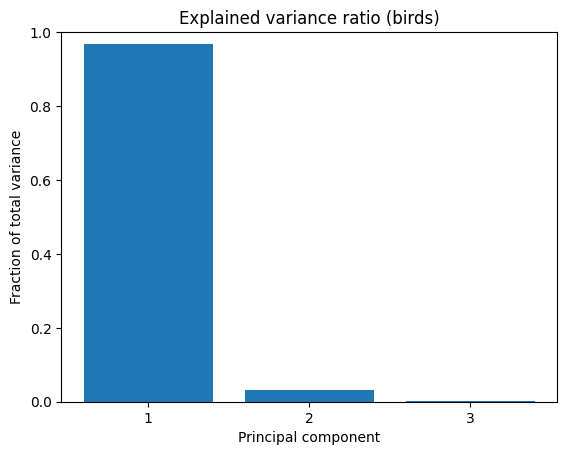

In [15]:

plt.figure()
plt.bar([1,2,3], evr_b)
plt.title("Explained variance ratio (birds)")
plt.xlabel("Principal component")
plt.ylabel("Fraction of total variance")
plt.xticks([1,2,3])
plt.ylim(0, 1)
plt.show()



### 7.2 Reconstruction with $k=1$ and $k=2$

With $U_k=[\mathbf{u}_1~\cdots~\mathbf{u}_k]$,
$$
Z_k = Y U_k,\qquad \hat{X}_k = \boldsymbol{\mu} + Z_k U_k^\top.
$$

We compare mean-squared reconstruction error (MSE) for $k=1$ and $k=2$.


In [16]:

Z1b = project(Yb, Ub, k=1)
Xhat1b = reconstruct(Z1b, mub, Ub, k=1)

Z2b = project(Yb, Ub, k=2)
Xhat2b = reconstruct(Z2b, mub, Ub, k=2)

mse1 = np.mean((Xb - Xhat1b)**2, axis=0)
mse2 = np.mean((Xb - Xhat2b)**2, axis=0)

print("Per-feature MSE (k=1):", dict(zip(feature_names, mse1)))
print("Per-feature MSE (k=2):", dict(zip(feature_names, mse2)))
print("\nTotal MSE (k=1):", float(np.mean((Xb - Xhat1b)**2)))
print("Total MSE (k=2):", float(np.mean((Xb - Xhat2b)**2)))


Per-feature MSE (k=1): {'length': np.float64(1.6580010960534965), 'wingspan': np.float64(0.552708816658375), 'weight': np.float64(0.870957450897747)}
Per-feature MSE (k=2): {'length': np.float64(0.03557597982128561), 'wingspan': np.float64(0.00453778913273207), 'weight': np.float64(0.11071692036484612)}

Total MSE (k=1): 1.0272224545365398
Total MSE (k=2): 0.05027689643962125



## 8. Why centering matters (math + demo)

If you skip centering, you are effectively analyzing second moments about the origin, not variance about the mean.
PCA is intended to capture directions of *variation around the mean*, so we use $Y = X-\mu$.


In [17]:

S_centered = covariance_matrix(Yb, ddof=1)

# Not a covariance: second moment about origin (included only to show distortion)
n = Xb.shape[0]
S_uncentered = (Xb.T @ Xb) / (n-1)

evals_c, U_c = pca_from_cov(S_centered)
evals_u, U_u = pca_from_cov(S_uncentered)

print("Centered eigenvalues:", evals_c)
print("Uncentered eigenvalues:", evals_u)
print("\nCentered PC1:", U_c[:,0])
print("Uncentered PC1:", U_u[:,0])


Centered eigenvalues: [90.063757  2.942607  0.151436]
Uncentered eigenvalues: [5868.255478    3.650967    0.15904 ]

Centered PC1: [-0.458871 -0.884805 -0.080985]
Uncentered PC1: [-0.39547  -0.9181   -0.026379]



## 9. Summary

You can now:
- compute PCA from scratch via $S = \frac{1}{n-1}Y^T Y$
- prove PC1 maximizes projected variance using Lagrange multipliers
- compute eigenpairs **by hand** in 2D (Exercise 2)
- interpret eigenvectors as loadings and eigenvalues as explained variance
- project and reconstruct with the first $k$ PCs

### Next optional extensions
- Standardize features (z-scores) and compare covariance-PCA vs correlation-PCA
- Use SVD and show it matches covariance PCA
- Apply to real bird CSV (replace synthetic generator)
